## 2 Whisper Baseline

This notebook will get the baseline WER and CER scores for Romansh. For this the test set each idiom will be decoded with both OpenAI's Whisper and Meta's Omnilingual. While Whisper is not trained on Romansh, Omnilingual is trained on Sursilvan.

In [2]:
import torch
import pandas as pd
import numpy as np
from omnilingual_asr.models.inference.pipeline import ASRInferencePipeline
from omnilingual_asr.models.wav2vec2_llama.lang_ids import supported_langs
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from torch.utils.data import Dataset, DataLoader
import librosa
from tqdm import tqdm
from jiwer import wer
import matplotlib.pyplot as plt
import warnings
from helpers import get_best_gpu, load_all_data
warnings.filterwarnings("ignore")

OSError: libcudart.so.13: cannot open shared object file: No such file or directory

For now we will use the Whisper Medium and Omnilingual 1B models, the constants can however be changed to use any other model.

In [2]:
WHISPER_MODEL = "medium"
OMNILINGUAL_MODEL = "omniASR_CTC_1B_v2"
LANGUAGE_CODE = "roh_Latn_surs1244"
BATCH_SIZE = 8
DEVICE = torch.device(f"cuda:{get_best_gpu()}" if torch.cuda.is_available() else "cpu")

Selected GPU 7 with 24121 MiB free memory


First we load all the test data and concatenate it to one dataframe.

In [3]:
df_test = load_all_data("test")
print(f"\nTotal test samples: {len(df_test)}")


Total test samples: 631


Then we can start transcribing with Whisper.

In [4]:
processor = WhisperProcessor.from_pretrained(f"openai/whisper-{WHISPER_MODEL}")
model = WhisperForConditionalGeneration.from_pretrained(f"openai/whisper-{WHISPER_MODEL}").to(DEVICE)

class AudioDataset(Dataset):
    def __init__(self, audio_paths, processor):
        self.audio_paths = audio_paths
        self.processor = processor

    def __len__(self):
        return len(self.audio_paths)

    def __getitem__(self, idx):
        audio_path = self.audio_paths[idx]
        audio, sr = librosa.load(audio_path, sr=16000)
        # Process to features
        input_features = self.processor(
            audio, 
            sampling_rate=16000, 
            return_tensors="pt"
        ).input_features[0]  # Remove batch dimension
        return input_features

def collate_fn(batch):
    """Custom collate function to handle different sized tensors"""
    # Find max length in batch
    max_len = max(f.shape[-1] for f in batch)
    
    # Pad all features to max length
    padded_batch = []
    for features in batch:
        pad_len = max_len - features.shape[-1]
        if pad_len > 0:
            padding = torch.zeros((features.shape[0], pad_len))
            padded = torch.cat([features, padding], dim=-1)
        else:
            padded = features
        padded_batch.append(padded)
    
    # Stack into batch
    return torch.stack(padded_batch)

# Create dataset and dataloader
dataset = AudioDataset(df_test["audio_path"], processor)
dataloader = DataLoader(
    dataset, 
    batch_size=8, 
    shuffle=False, 
    collate_fn=collate_fn, 
    num_workers=0
)

whisper_transcriptions = []

for batch in tqdm(dataloader, desc="Transcribing (batched)"):
    batch = batch.to(DEVICE)
    with torch.no_grad():
        predicted_ids = model.generate(
            batch,
            max_length=225,
            num_beams=1,
            task="transcribe"
        )
    texts = processor.batch_decode(predicted_ids, skip_special_tokens=True)
    whisper_transcriptions.extend(texts)

df_test['whisper_transcription'] = whisper_transcriptions

Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

Transcribing (batched):   0%|          | 0/79 [00:00<?, ?it/s]The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom 

Then we can transcribe with Omnilingual.

In [5]:
if LANGUAGE_CODE in supported_langs:
    print(f"{LANGUAGE_CODE} supported")
else:
    print(f"{LANGUAGE_CODE} not in supported list")

omnilingual_pipeline = ASRInferencePipeline(model_card=OMNILINGUAL_MODEL, device=DEVICE)

print(f"\nTranscribing {len(df_test)} files with Omnilingual...")
omnilingual_transcriptions = []

for i in range(0, len(df_test), BATCH_SIZE):
    batch_paths = df_test['audio_path'].iloc[i:i+BATCH_SIZE].tolist()
    try:
        results = omnilingual_pipeline.transcribe(
            batch_paths,
            lang=[LANGUAGE_CODE] * len(batch_paths),
            batch_size=len(batch_paths)
        )
        omnilingual_transcriptions.extend(results)
    except Exception as e:
        print(f"Batch error: {e}")
        omnilingual_transcriptions.extend([""] * len(batch_paths))
    
    print(f"Processed {min(i+BATCH_SIZE, len(df_test))}/{len(df_test)} files")

df_test['omnilingual_transcription'] = omnilingual_transcriptions

roh_Latn_surs1244 supported


Output()


Transcribing 631 files with Omnilingual...
Processed 8/631 files
Processed 16/631 files
Processed 24/631 files
Processed 32/631 files
Processed 40/631 files
Processed 48/631 files
Processed 56/631 files
Batch error: The map function has failed while processing the path 'data' of the input data. See nested exception for details.
Processed 64/631 files
Processed 72/631 files
Processed 80/631 files
Processed 88/631 files
Processed 96/631 files
Processed 104/631 files
Processed 112/631 files
Processed 120/631 files
Processed 128/631 files
Processed 136/631 files
Processed 144/631 files
Processed 152/631 files
Processed 160/631 files
Processed 168/631 files
Processed 176/631 files
Processed 184/631 files
Processed 192/631 files
Processed 200/631 files
Processed 208/631 files
Processed 216/631 files
Processed 224/631 files
Processed 232/631 files
Processed 240/631 files
Processed 248/631 files
Processed 256/631 files
Processed 264/631 files
Processed 272/631 files
Processed 280/631 files
Pr

After we obtained the transcriptions, the Word Error Rate (WER) can be computed.

In [6]:
def compute_wer(ref, hyp):
    if ref and hyp:
        try:
            return wer(ref, hyp)
        except:
            return None
    return None

df_test['whisper_wer'] = df_test.apply(
    lambda row: compute_wer(row['sentence'], row['whisper_transcription']), axis=1
)
df_test['omnilingual_wer'] = df_test.apply(
    lambda row: compute_wer(row['sentence'], row['omnilingual_transcription']), axis=1
)

print("Per-sample WER computed")
print("\nFirst 5 rows:")
print(df_test[['idiom', 'whisper_wer', 'omnilingual_wer']].head())

Per-sample WER computed

First 5 rows:
      idiom  whisper_wer  omnilingual_wer
0  Surmiran     0.897436         0.769231
1  Surmiran     0.722222         0.666667
2  Surmiran     0.804348         0.630435
3  Surmiran     0.931034         0.586207
4  Surmiran     0.965517         0.568966


Then we obtain the results per idiom. Unsurprisingly Whisper performs quite weakly since it does not support the language. Omnilingual on the other hand does a bit better.

In [7]:
idiom_summary = df_test.groupby('idiom').agg(
    samples=('sentence', 'count'),
    whisper_wer_mean=('whisper_wer', 'mean'),
    whisper_wer_std=('whisper_wer', 'std'),
    omnilingual_wer_mean=('omnilingual_wer', 'mean'),
    omnilingual_wer_std=('omnilingual_wer', 'std')
).reset_index()

overall = pd.DataFrame({
    'idiom': ['OVERALL'],
    'samples': [len(df_test)],
    'whisper_wer_mean': [df_test['whisper_wer'].mean()],
    'whisper_wer_std': [df_test['whisper_wer'].std()],
    'omnilingual_wer_mean': [df_test['omnilingual_wer'].mean()],
    'omnilingual_wer_std': [df_test['omnilingual_wer'].std()]
})

idiom_summary = pd.concat([idiom_summary, overall], ignore_index=True)
idiom_summary = idiom_summary.round(4)
idiom_summary[['whisper_wer_mean', 'omnilingual_wer_mean']] *= 100

print("\nPer-idiom WER summary (%):")
print(idiom_summary.to_string(index=False))


Per-idiom WER summary (%):
    idiom  samples  whisper_wer_mean  whisper_wer_std  omnilingual_wer_mean  omnilingual_wer_std
    Puter      114            102.61           0.4120                 73.86               0.2468
       RG       81             92.66           0.3024                 55.04               0.1148
 Surmiran      151            109.81           0.7559                 82.34               0.1735
Sursilvan       94            100.64           0.2227                 75.76               0.1065
Sutsilvan       94            107.85           0.4679                 84.47               0.0937
 Vallader       97             99.49           0.2525                 73.78               0.1484
  OVERALL      631            103.06           0.4802                 75.23               0.1840


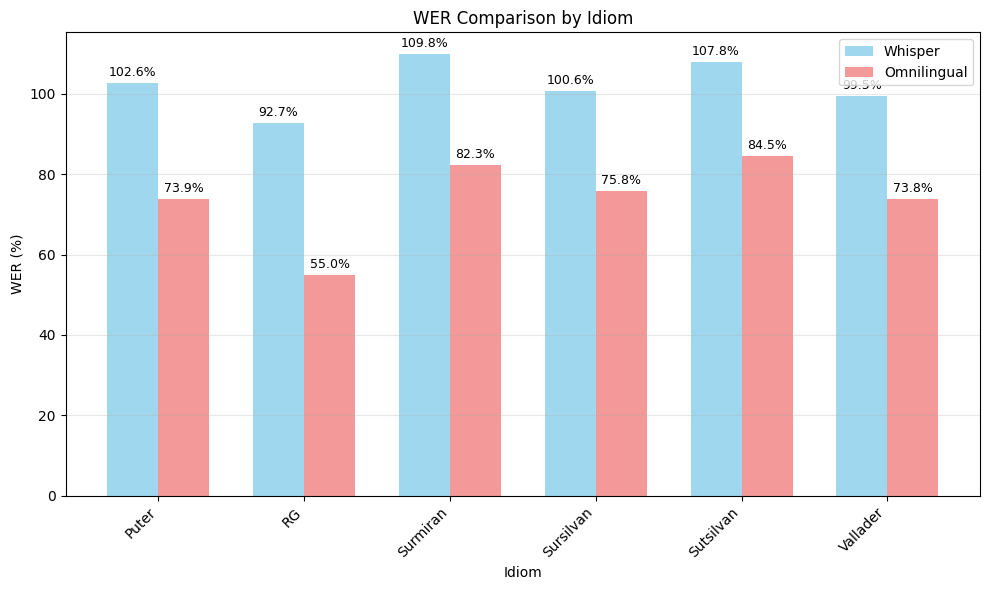

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

idioms_plot = idiom_summary[:-1]   # exclude overall row
x = np.arange(len(idioms_plot))
width = 0.35

whisper_vals = idioms_plot['whisper_wer_mean'].values
omni_vals = idioms_plot['omnilingual_wer_mean'].values

bars1 = ax.bar(x - width/2, whisper_vals, width, label='Whisper', color='skyblue', alpha=0.8)
bars2 = ax.bar(x + width/2, omni_vals, width, label='Omnilingual', color='lightcoral', alpha=0.8)

ax.set_xlabel('Idiom')
ax.set_ylabel('WER (%)')
ax.set_title('WER Comparison by Idiom')
ax.set_xticks(x)
ax.set_xticklabels(idioms_plot['idiom'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [14]:
print("\n" + "="*60)
print("EXAMPLE TRANSCRIPTIONS")
print("="*60)

sample_rows = df_test.sample(min(5, len(df_test)), random_state=42)
for idx, row in sample_rows.iterrows():
    print(f"\nIdiom: {row['idiom']}")
    print(f"Reference: {row['sentence'][:150]}...")
    print(f"Whisper: {row['whisper_transcription'][:150]}...")
    print(f"Omnilingual: {row['omnilingual_transcription'][:150]}...")
    print(f"WER: Whisper={row['whisper_wer']*100:.1f}%, Omnilingual={row['omnilingual_wer']*100:.1f}%")
    print("-" * 40)


EXAMPLE TRANSCRIPTIONS

Idiom: Vallader
Reference: Ma, quai es tuots duos listess important, la il plü decisiv es la fiduzcha....
Whisper:  Aber das ist das Wichtigste. Die Fiduzie ist das Wichtigste....
Omnilingual: ma queis tots duos li stess important l plü dezisiv es la fiduzia...
WER: Whisper=100.0%, Omnilingual=71.4%
----------------------------------------

Idiom: Puter
Reference: E que es il cas. Perque ho la fundaziun premi grischun da litteratura decis da surder a Romana Ganzoni il premi grischun da litteratura da l'an 2 1000...
Whisper:  Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe...
Omnilingual: e qui es il cas perqui o la fundaziun premi grishum da literatura dezis da surdir a romana ganzoni il premi grischum da literatura da l'an duamilievin...
WER: Whisper=186.7%, Omnilingual=56.7%
----------------------------------------

Idiom: Sutsilvan
Reference: Ad ear igl suna